# Wine Quality Classification - LLM Comparison

Benchmark of three open-weights instruction-tuned LLMs (served locally via Ollama
at Q4_K_M quantisation) on a 3-class ordinal wine quality classification task over
expert review text, across four prompting strategies, with statistical significance
testing, supervised baselines evaluated under an identical protocol, and a
minority-class diagnostic.

**Models:**
- Qwen-2.5-14B-Instruct (Alibaba)
- Mistral-Nemo-12B-Instruct (Mistral AI)
- Gemma-3-12B-Instruct (Google)

**Prompting strategies:**
- Zero-shot
- Few-shot with K=4 random exemplars per class (12 demonstrations)
- Retrieval-Augmented few-shot, class-balanced (K=6, top-2 per class via BGE cosine similarity)
- Retrieval-Augmented few-shot, global top-K
- Self-consistency (majority vote over N=3 samples, temp=0.6) on the best single-shot cell

**Baselines (same protocol):** majority-class, TF-IDF + Logistic Regression (default & class-balanced)


## 0. Install dependencies

In [1]:
%pip install -q datasets ollama sentence-transformers pandas numpy matplotlib seaborn scipy scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


## Pull LLMs via Ollama (one-time)

Run these in PowerShell with `ollama serve` already started in another terminal:

```powershell
ollama pull qwen2.5:14b
ollama pull mistral-nemo:12b
ollama pull gemma3:12b
```

Approximate disk usage: ~22 GB total (each ~7-9 GB at Q4_K_M quantization).
At this size the weights effectively fill the 8 GB of VRAM; Ollama swaps models on
demand and may partially offload the KV cache to system RAM under long prompts.


## 1. Imports & Configuration

In [2]:
import os, time, re, gc, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    matthews_corrcoef, confusion_matrix,
)
warnings.filterwarnings("ignore")

import ollama

RANDOM_SEED       = 42
N_TEST_EVAL       = 500

N_RETRIEVAL_POOL  = None

FEWSHOT_K_RANDOM  = 4
RETRIEVAL_K       = 6
SC_NUM_SAMPLES    = 3
SC_TEMPERATURE    = 0.6
NUM_CLASSES       = 3
CLASS_NAMES       = ["Low", "Medium", "High"]

N_BOOTSTRAP       = 10000
N_LOW_DIAG        = 100

NUM_CTX           = 4096

LLM_MODELS = [
    ("qwen2.5:14b", "Qwen-2.5-14B"),
    ("mistral-nemo:12b", "Mistral-Nemo-12B"),
    ("gemma3:12b", "Gemma-3-12B"),
]

OLLAMA_OPTIONS_DETERMINISTIC = {
    "temperature": 0.0,
    "num_predict": 8,
    "top_p":       1.0,
    "num_ctx":     NUM_CTX,
}

OLLAMA_OPTIONS_SAMPLED = {
    "temperature": SC_TEMPERATURE,
    "num_predict": 4,
    "top_p":       0.95,
    "num_ctx":     NUM_CTX,
}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

print("Ollama version:", ollama.__version__ if hasattr(ollama, "__version__") else "unknown")
print(f"Eval test size : {N_TEST_EVAL}")
print(f"Retrieval pool : {'full training split' if N_RETRIEVAL_POOL is None else N_RETRIEVAL_POOL}")
print(f"Context window : {NUM_CTX}")
print(f"Models         : {[name for _, name in LLM_MODELS]}")


Ollama version: unknown
Eval test size : 500
Retrieval pool : full training split
Context window : 4096
Models         : ['Qwen-2.5-14B', 'Mistral-Nemo-12B', 'Gemma-3-12B']


## 2. Data Loading

`james-burton/wine_reviews_ordinal` (Burton 2023) - WineMag corpus reformulated for ordinal
classification, with predefined train / val / test splits.


In [3]:
from datasets import load_dataset

ds = load_dataset("james-burton/wine_reviews_ordinal")
train_raw = ds["train"].to_pandas()
val_raw   = ds["validation"].to_pandas()
test_raw  = ds["test"].to_pandas()

print(f"Train: {len(train_raw):,} | Val: {len(val_raw):,} | Test: {len(test_raw):,}")

def normalise(df):
    df = df.rename(columns={
        "description": "review",
        "points":      "rating",
        "province":    "region",
    }).copy()
    df = df.dropna(subset=["rating", "review"]).reset_index(drop=True)
    df = df[df["review"].astype(str).str.strip().str.len() > 10].reset_index(drop=True)
    df["price"]   = pd.to_numeric(df["price"], errors="coerce")
    df["country"] = df["country"].fillna("Unknown").astype(str)
    df["region"]  = df["region"].fillna("Unknown").astype(str)
    return df

train_df = normalise(train_raw)
val_df   = normalise(val_raw)
test_df  = normalise(test_raw)

VARIETY_NAMES = [
    "Bordeaux-style Red Blend", "Bordeaux-style White Blend", "Cabernet Franc",
    "Cabernet Sauvignon", "Champagne Blend", "Chardonnay", "Gamay",
    "Gew\u00fcrztraminer", "Gr\u00fcner Veltliner", "Malbec", "Merlot", "Nebbiolo",
    "Pinot Grigio", "Pinot Gris", "Pinot Noir", "Portuguese Red",
    "Portuguese White", "Red Blend", "Rh\u00f4ne-style Red Blend", "Riesling",
    "Ros\u00e9", "Sangiovese", "Sauvignon Blanc", "Shiraz", "Sparkling Blend",
    "Syrah", "Tempranillo", "Viognier", "White Blend", "Zinfandel",
]
for _df in (train_df, val_df, test_df):
    _df["variety_name"] = _df["variety"].map(
        lambda v: VARIETY_NAMES[int(v)]
        if pd.notna(v) and 0 <= int(v) < len(VARIETY_NAMES) else "Unknown")

print(f"After cleaning - Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
train_df.head(2)

Train: 71,504 | Val: 12,619 | Test: 21,031
After cleaning - Train: 71,504 | Val: 12,619 | Test: 21,031


,country,review,rating,price,region,variety,variety_name
0,France,"Although it's not indicated on the label, this...",92,NaN,Champagne,5,Chardonnay
1,US,"A touch salty on the entry, this wine offers s...",84,17.0,California,5,Chardonnay


## 3. Quality-Tier Binning

Quality scores (80-100) are partitioned into 3 ordinal classes (Low / Medium / High)
using fixed thresholds {82, 90} derived a priori from WineEnthusiast's editorial
review tiers (acceptable | good + very good | excellent + superb + classic) —
not fitted from the data.


In [4]:
bins = [80, 82, 90, 100]

def make_label(rating):
    if rating <= 82:
        return 0
    elif rating <= 90:
        return 1
    else:
        return 2

train_df["label"] = train_df["rating"].apply(make_label)
val_df["label"]   = val_df["rating"].apply(make_label)
test_df["label"]  = test_df["rating"].apply(make_label)

print(f"\nBin edges: {bins}")

print("\nTrain class distribution:")
print(train_df["label"].value_counts(normalize=True).sort_index().round(3).to_dict())

print("\nValidation class distribution:")
print(val_df["label"].value_counts(normalize=True).sort_index().round(3).to_dict())

print("\nTest class distribution:")
print(test_df["label"].value_counts(normalize=True).sort_index().round(3).to_dict())

print("\nClass definitions:")
print(f"Class 0: 80 <= rating <= 82")
print(f"Class 1: 82 < rating <= 90")
print(f"Class 2: 90 < rating <= 100")


Bin edges: [80, 82, 90, 100]

Train class distribution:
{0: 0.023, 1: 0.703, 2: 0.274}

Validation class distribution:
{0: 0.023, 1: 0.7, 2: 0.277}

Test class distribution:
{0: 0.021, 1: 0.703, 2: 0.275}

Class definitions:
Class 0: 80 <= rating <= 82
Class 1: 82 < rating <= 90
Class 2: 90 < rating <= 100


## 4. Sample Test Subset + Retrieval Pool

A deterministic, class-stratified subset of `N_TEST_EVAL = 500` test reviews keeps
total runtime manageable (3 LLMs × 4 strategies × 500 calls) while giving accuracy
estimates a bootstrap 95% CI of roughly ±3 pp.

The retrieval pool is the **full training split** (71,504 reviews). Pool size was
selected on the validation split, never on test (`llm_pool_validation.csv`): the
full pool beat the earlier 3,000-review stratified subsample by +5.3 pp accuracy
(exact McNemar p = 0.014) because a 24× denser pool yields substantially closer
nearest neighbours. K = 12 exemplars lost to K = 6 (p = 0.029), so `RETRIEVAL_K`
stays at 6.

In [5]:
def stratified_subsample(df, n, seed=RANDOM_SEED):
    parts = []
    class_counts = df["label"].value_counts(normalize=True)
    for k, prop in class_counts.items():
        g = df[df["label"] == k]
        n_k = max(1, round(n * prop))
        parts.append(g.sample(n=min(n_k, len(g)), random_state=seed))
    out = pd.concat(parts, ignore_index=True)
    return out.sample(frac=1, random_state=seed).reset_index(drop=True)

test_eval_df = stratified_subsample(test_df, N_TEST_EVAL)

if N_RETRIEVAL_POOL is None:
    retrieval_pool = train_df.reset_index(drop=True)
else:
    retrieval_pool = stratified_subsample(train_df, N_RETRIEVAL_POOL)

print(f"\nTest eval subset size: {len(test_eval_df)}")
print("Test class distribution:")
print(test_eval_df["label"].value_counts().sort_index().to_dict())

print(f"\nRetrieval pool size: {len(retrieval_pool)}")
print("Pool class distribution:")
print(retrieval_pool["label"].value_counts().sort_index().to_dict())


Test eval subset size: 501
Test class distribution:
{0: 11, 1: 352, 2: 138}

Retrieval pool size: 71504
Pool class distribution:
{0: 1627, 1: 50292, 2: 19585}


## 5. SBERT Embeddings (for retrieval-augmented few-shot)

Encode the retrieval pool and test subset with `BAAI/bge-large-en-v1.5` (frozen,
1024-dim). L2-normalized embeddings allow cosine similarity to be computed as a
simple dot product.

Encoding the full 71.5k-review pool takes ~10 minutes on the GPU (one-time per
session; ~290 MB in RAM as float32).

In [6]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "BAAI/bge-large-en-v1.5"
sbert = SentenceTransformer(model_name, device=device)

print(f"Model: {model_name}")
print(f"Device: {device}")
print(f"Embedding dim: {sbert.get_sentence_embedding_dimension()}")

retrieval_pool["review"] = retrieval_pool["review"].fillna("")
test_eval_df["review"] = test_eval_df["review"].fillna("")

print("Encoding retrieval pool...")
pool_emb = sbert.encode(
    retrieval_pool["review"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Encoding test set...")
test_emb = sbert.encode(
    test_eval_df["review"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

del sbert
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Pool embeddings : {pool_emb.shape}")
print(f"Test embeddings : {test_emb.shape}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Model: BAAI/bge-large-en-v1.5
Device: cuda
Embedding dim: 1024
Encoding retrieval pool...


Batches:   0%|          | 0/559 [00:00<?, ?it/s]

Encoding test set...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Pool embeddings : (71504, 1024)
Test embeddings : (501, 1024)


## 6. Prompt Templates

We use a unified system prompt across all experimental strategies, combined with three exemplar selection schemes: zero-shot, random few-shot, and retrieval-augmented few-shot.

The model is instructed to perform ordinal wine quality classification and to output exactly one label: 0 (low), 1 (medium), or 2 (high). No structured output format (e.g., JSON) is used in order to avoid format instability across different LLMs.

This design improves robustness and ensures consistent evaluation across models that may not strictly follow structured output instructions.

In [7]:

SYSTEM_PROMPT = (
    "You are a professional wine judge.\n"
    "You must classify wines into exactly one class.\n\n"

    "Wine quality classes (WineEnthusiast tiers):\n"
    "0 = Low (80-82 points): flawed or very plain wines. Typical language: thin, "
    "vegetal, sour, bitter, green, dull, harsh, overripe, lacks.\n"
    "1 = Medium (83-90 points): correct to very good everyday wines. Typical "
    "language: pleasant, balanced, easy, straightforward, crisp, clean, fruity, drink now.\n"
    "2 = High (91-100 points): excellent to classic wines. Typical language: "
    "complex, concentrated, elegant, velvety, opulent, layered, refined, "
    "structured, minerality, long finish, ageworthy.\n\n"

    "Statistical priors measured on thousands of expert reviews - use them as "
    "priors, the review text always has the final word:\n"
    "- Base rates: about 2 percent of all wines are Low, 70 percent Medium "
    "and 28 percent High - when signals conflict, Medium is the safest call.\n"
    "- Price ladder: under 10 USD is never High and often Low; 10-30 USD is "
    "mostly Medium; 30-50 USD is a Medium/High toss-up; 50-100 USD is likely "
    "High; over 100 USD is very likely High; over 300 USD is virtually always "
    "High. Unknown price leans Medium, sometimes High.\n"
    "- Review length ladder (the length is given to you): under 190 characters "
    "is almost never High and carries real Low risk; 190-270 is usually "
    "Medium; 271-352 is an even Medium/High split; 353-433 is typically High; "
    "over 433 is almost always High.\n"
    "- Strong combinations: a detailed review (over 350 chars) of a wine over "
    "50 USD is High in 9 of 10 cases; a short review (under 190 chars) of a "
    "wine under 15 USD is never High and often Low.\n"
    "- Variety priors: Nebbiolo, Gruener Veltliner, Pinot Noir, Champagne "
    "Blend, Syrah and Riesling lean High; Pinot Grigio, Rose, Portuguese "
    "White, White Blend, Sauvignon Blanc and Merlot rarely reach High.\n"
    "- Origin priors: Austria and Germany lean High; Champagne, Piedmont, "
    "Burgundy, Mosel, Alsace, Douro and Oregon lean High; Chile, most Spanish "
    "and Argentine regions, and New York lean Low-to-Medium.\n"
    "- The decisive boundary is Medium vs High (90 vs 91 points): High needs "
    "genuine superlatives, complexity/structure language or ageing potential; "
    "merely 'very good' is Medium.\n"
    "- Low is rare (about 2 percent of wines): reserve it for clearly "
    "negative reviews.\n\n"

    "CRITICAL RULES:\n"
    "- Output ONLY one digit: 0, 1, or 2\n"
    "- No explanation\n"
    "- No punctuation\n"
    "- No extra text"
)

def format_wine(row):
    price_str = f"{row['price']:.0f} USD" if pd.notna(row['price']) else "unknown"
    header = f"Country: {row['country']} | Region: {row['region']} | Price: {price_str}"
    if "variety_name" in row.index:
        header += f" | Variety: {row['variety_name']}"
    text = str(row["review"])
    header += f" | Review length: {len(text)} chars"
    return f"{header}\nReview: {text}"

def format_exemplar(row):
    return f"{format_wine(row)}\nClass: {int(row['label'])}"

def build_prompt_zeroshot(test_row):
    user = (
        "Classify this wine.\n"
        "Return ONLY one digit: 0, 1, or 2.\n\n"
        f"{format_wine(test_row)}"
    )
    return SYSTEM_PROMPT, user

def build_prompt_fewshot_random(test_row, rng):
    examples = []
    for k in range(NUM_CLASSES):
        pool = retrieval_pool[retrieval_pool["label"] == k]
        idx = rng.choice(len(pool), size=FEWSHOT_K_RANDOM, replace=False)
        for i in idx:
            examples.append(format_exemplar(pool.iloc[i]))
    rng.shuffle(examples)

    user = (
        "Labeled wine examples:\n\n"
        + "\n\n".join(examples)
        + "\n\n"
        "Now classify the final wine.\n\n"
        f"{format_wine(test_row)}\n\n"
        "Return ONLY: 0, 1, or 2"
    )
    return SYSTEM_PROMPT, user

def retrieve_exemplars(query_emb, balanced=True):
    """Return the RETRIEVAL_K most similar pool exemplars for a query embedding.

    balanced=True  -> class-balanced: top-(K/3) neighbours per class (proposed method)
    balanced=False -> global top-K regardless of class (unbalanced ablation)
    """
    sims = pool_emb @ query_emb
    examples = []
    if balanced:
        per_class = max(1, RETRIEVAL_K // NUM_CLASSES)
        for k in range(NUM_CLASSES):
            mask = retrieval_pool["label"].values == k
            class_sims = sims.copy()
            class_sims[~mask] = -np.inf
            top = np.argsort(-class_sims)[:per_class]
            for i in top:
                examples.append(format_exemplar(retrieval_pool.iloc[i]))
    else:
        top = np.argsort(-sims)[:RETRIEVAL_K]
        for i in top:
            examples.append(format_exemplar(retrieval_pool.iloc[i]))
    return examples

def build_retrieval_user_prompt(test_row, examples, shuffle_seed):
    rng = np.random.RandomState(shuffle_seed)
    rng.shuffle(examples)
    return (
        "Similar wines for reference:\n\n"
        + "\n\n".join(examples)
        + "\n\n"
        "Now classify the final wine based on its own merits.\n\n"
        f"{format_wine(test_row)}\n\n"
        "Return ONLY one digit: 0, 1, or 2"
    )

def build_prompt_retrieval(test_row, test_idx):
    examples = retrieve_exemplars(test_emb[test_idx], balanced=True)
    return SYSTEM_PROMPT, build_retrieval_user_prompt(test_row, examples, test_idx)

def build_prompt_retrieval_global(test_row, test_idx):
    examples = retrieve_exemplars(test_emb[test_idx], balanced=False)
    return SYSTEM_PROMPT, build_retrieval_user_prompt(test_row, examples, test_idx)

## 7. LLM Runner + Robust Output Parsing

We send chat requests to Ollama and extract the predicted label from the model output.

Since models exhibit format drift (e.g., returning JSON, plain text, or mixed formats), we do not enforce structured outputs. Instead, we use a simple and robust parsing strategy that extracts the first valid class label (0, 1, or 2) from the response.

Parse failures are rare and are handled by assigning a default class (medium = 1), and are tracked separately for analysis.

In [8]:
def parse_label(text):
    if not text:
        return None

    text = str(text).strip()

    if text in {"0", "1", "2"}:
        return int(text)

    import re
    m = re.search(r"\b[012]\b", text)
    if m:
        return int(m.group(0))

    return None

def call_llm(model, system, user, options=None):
    if options is None:
        options = OLLAMA_OPTIONS_DETERMINISTIC

    try:
        resp = ollama.chat(
            model=model,
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": user}
            ],
            options=options,
        )
        return resp["message"]["content"]

    except Exception as e:
        return ""

def build_prompt(strategy, row, i, rng_local):
    if strategy == "zero_shot":
        return build_prompt_zeroshot(row)
    elif strategy == "fewshot_random":
        return build_prompt_fewshot_random(row, rng_local)
    elif strategy == "retrieval":
        return build_prompt_retrieval(row, i)
    elif strategy == "retrieval_global":
        return build_prompt_retrieval_global(row, i)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

def evaluate_strategy(model_name, model_id, strategy, test_subset,
                      options=None):

    rng_local = np.random.RandomState(RANDOM_SEED)

    preds, true, raw_outputs = [], [], []
    parse_failures = 0

    t0 = time.time()

    desc = f"{model_name:>16s} | {strategy:<16s}"

    for i, (_, row) in enumerate(tqdm(
            test_subset.iterrows(),
            total=len(test_subset),
            desc=desc)):

        sys_p, user_p = build_prompt(strategy, row, i, rng_local)

        out = call_llm(model_id, sys_p, user_p, options=options)
        raw_outputs.append(out)

        pred = parse_label(out)

        if pred is None:
            parse_failures += 1
            pred = 1

        preds.append(pred)
        true.append(int(row["label"]))

        if i < 3:
            print("RAW:", out)
            print("PRED:", pred)
            print("TRUE:", row["label"])

    elapsed = time.time() - t0

    return {
        "model": model_name,
        "model_id": model_id,
        "strategy": strategy,
        "preds": np.array(preds),
        "labels": np.array(true),
        "raw": raw_outputs,
        "parse_failures": parse_failures,
        "elapsed_s": elapsed,
    }

## 7b. Quick Sanity Check

Issue one prompt to each model to confirm Ollama is reachable and the model is
loaded into VRAM. If a model fails here, pull it via `ollama pull <name>`.


In [9]:
for model_id, model_name in LLM_MODELS:
    try:
        sys_p, user_p = build_prompt_zeroshot(test_eval_df.iloc[0])
        t0  = time.time()
        out = call_llm(model_id, sys_p, user_p)
        dt  = time.time() - t0
        pred = parse_label(out)
        true = int(test_eval_df.iloc[0]["label"])
        print(f"[OK] {model_name:<18s} latency={dt:.1f}s  pred={pred}  true={true}")
        print(f"     raw: {out[:200]!r}")
    except Exception as e:
        print(f"[ERR] {model_name}: {e}")


[OK] Qwen-2.5-14B       latency=11.9s  pred=2  true=2
     raw: '2'
[OK] Mistral-Nemo-12B   latency=10.0s  pred=2  true=2
     raw: '2'
[OK] Gemma-3-12B        latency=14.5s  pred=2  true=2
     raw: '2'


## 8. Main Sweep: 3 Models x 4 Strategies (with checkpointing)

The `retrieval_global` strategy is the unbalanced counterpart of class-balanced
retrieval: identical prompt format, but the K=6 exemplars are the global top-K
neighbours regardless of class, instead of top-2 per class. Comparing the two
isolates the specific effect of class balancing.

Every completed (model, strategy) run is checkpointed to `llm_runs_checkpoint.pkl`.
If the kernel dies mid-sweep, re-run the notebook top-to-bottom: finished runs are
loaded from the checkpoint and skipped. Delete the checkpoint file to force a full
re-run.

In [10]:
import pickle

assert N_RETRIEVAL_POOL is None and len(retrieval_pool) == len(train_df), (
    "CONFIG REGRESSED: retrieval pool is not the full training split!")
assert OLLAMA_OPTIONS_DETERMINISTIC.get("num_ctx", 0) >= 4096, (
    "CONFIG REGRESSED: num_ctx fix is missing!")

STRATEGIES = ["zero_shot", "fewshot_random", "retrieval", "retrieval_global"]
CHECKPOINT_PATH = "llm_runs_checkpoint.pkl"

all_runs = []
done = set()
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, "rb") as f:
        all_runs = pickle.load(f)
    all_runs = [r for r in all_runs if len(r["labels"]) == len(test_eval_df)]
    done = {(r["model"], r["strategy"]) for r in all_runs}
    print(f"Resumed {len(all_runs)} completed runs from checkpoint:")
    for m, s in sorted(done):
        print(f"   - {m} / {s}")

for model_id, model_name in LLM_MODELS:
    for strategy in STRATEGIES:
        if (model_name, strategy) in done:
            continue
        run = evaluate_strategy(model_name, model_id, strategy, test_eval_df)
        acc = accuracy_score(run["labels"], run["preds"])
        print(f"--> {model_name:<18s} {strategy:<16s}  acc={acc:.4f}  "
               f"parse_fails={run['parse_failures']:3d}/{len(test_eval_df)}  "
               f"time={run['elapsed_s']/60:.1f}min")
        all_runs.append(run)
        with open(CHECKPOINT_PATH, "wb") as f:
            pickle.dump(all_runs, f)


    Qwen-2.5-14B | zero_shot       :   0%|          | 0/501 [00:00<?, ?it/s]

RAW: 2
PRED: 2
TRUE: 2
RAW: 1
PRED: 1
TRUE: 1
RAW: 2
PRED: 2
TRUE: 2
--> Qwen-2.5-14B       zero_shot         acc=0.7864  parse_fails=  0/501  time=6.5min


    Qwen-2.5-14B | fewshot_random  :   0%|          | 0/501 [00:00<?, ?it/s]

RAW: 2
PRED: 2
TRUE: 2
RAW: 1
PRED: 1
TRUE: 1
RAW: 2
PRED: 2
TRUE: 2
--> Qwen-2.5-14B       fewshot_random    acc=0.7006  parse_fails=  0/501  time=22.4min


    Qwen-2.5-14B | retrieval       :   0%|          | 0/501 [00:00<?, ?it/s]

...

RAW: 2
PRED: 2
TRUE: 2
RAW: 1
PRED: 1
TRUE: 1
RAW: 2
PRED: 2
TRUE: 2
--> Gemma-3-12B        fewshot_random    acc=0.7864  parse_fails=  0/501  time=30.4min


     Gemma-3-12B | retrieval       :   0%|          | 0/501 [00:00<?, ?it/s]

RAW: 1
PRED: 1
TRUE: 2
RAW: 1
PRED: 1
TRUE: 1
RAW: 2
PRED: 2
TRUE: 2
--> Gemma-3-12B        retrieval         acc=0.8263  parse_fails=  0/501  time=23.8min


     Gemma-3-12B | retrieval_global:   0%|          | 0/501 [00:00<?, ?it/s]

RAW: 2
PRED: 2
TRUE: 2
RAW: 1
PRED: 1
TRUE: 1
RAW: 2
PRED: 2
TRUE: 2
--> Gemma-3-12B        retrieval_global  acc=0.8683  parse_fails=  0/501  time=23.8min


## 9. Self-Consistency on the Best (Model, Strategy)

For the highest-scoring (model, strategy) pair, draw N=3 sampled completions per
test instance (temperature 0.6) and take the majority vote. Note: the literature
reports gains mainly when the deterministic baseline is uncertain; on an
already-strong cell, stochastic resampling can just as easily inject label noise
(as observed in our original N=100 run: 0.90 -> 0.87).


In [11]:
single_shot_llm_runs = [
    r for r in all_runs
    if r.get("model_id") and not r["strategy"].endswith("_sc")
]
best_run = max(single_shot_llm_runs,
               key=lambda r: accuracy_score(r["labels"], r["preds"]))
print(f"Best so far: {best_run['model']} + {best_run['strategy']} -> "
      f"acc {accuracy_score(best_run['labels'], best_run['preds']):.4f}")

already_done_sc = any(r["strategy"].endswith("_sc") for r in all_runs)

if already_done_sc:
    print("Self-consistency run already present (from checkpoint) - skipping.")
else:
    print(f"\nRunning self-consistency (N={SC_NUM_SAMPLES} samples per item)...")

    rng_sc = np.random.RandomState(RANDOM_SEED)

    sc_preds, sc_true, sc_failures = [], [], 0

    t0 = time.time()

    for i, (_, row) in enumerate(tqdm(test_eval_df.iterrows(),
                                      total=len(test_eval_df),
                                      desc="self-consistency")):

        sys_p, user_p = build_prompt(best_run["strategy"], row, i, rng_sc)

        user_p = user_p + "\n\nIMPORTANT: Re-evaluate carefully and output only 0, 1, or 2."

        samples = []

        for _ in range(SC_NUM_SAMPLES):
            out = call_llm(
                best_run["model_id"],
                sys_p,
                user_p,
                options=OLLAMA_OPTIONS_SAMPLED
            )

            pred = parse_label(out)

            if pred is not None:
                samples.append(pred)

        if len(samples) == 0:
            sc_failures += 1
            majority = NUM_CLASSES // 2
        else:
            majority = Counter(samples).most_common(1)[0][0]

        sc_preds.append(majority)
        sc_true.append(int(row["label"]))

    sc_run = {
        "model": best_run["model"] + " (SC)",
        "model_id": best_run["model_id"],
        "strategy": best_run["strategy"] + "_sc",
        "preds": np.array(sc_preds),
        "labels": np.array(sc_true),
        "raw": None,
        "parse_failures": sc_failures,
        "elapsed_s": time.time() - t0,
    }

    all_runs.append(sc_run)
    with open(CHECKPOINT_PATH, "wb") as f:
        pickle.dump(all_runs, f)

    print(f"\nSelf-consistency acc: {accuracy_score(sc_run['labels'], sc_run['preds']):.4f}  "
          f"(time {sc_run['elapsed_s']/60:.1f}min)")

Best so far: Gemma-3-12B + retrieval_global -> acc 0.8683

Running self-consistency (N=3 samples per item)...


self-consistency:   0%|          | 0/501 [00:00<?, ?it/s]


Self-consistency acc: 0.8523  (time 45.2min)


## 9b. Classical ML Baselines (same protocol)

Traditional supervised baselines evaluated under the *identical* protocol: the
input is the exact same serialised text the LLMs see (`format_wine`: country |
region | price | variety | review length + full review text), and evaluation
uses the same stratified test subset.

- **Majority-class**: always predicts Medium (the 70% prior) - the floor any model must beat.
- **TF-IDF + Logistic Regression**: word 1-2-grams, trained on the full 71.5k training split.
- **TF-IDF + Logistic Regression (balanced)**: same, with `class_weight="balanced"` -
  typically trades a little accuracy for better minority-class recall.

These run on CPU in a couple of minutes.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

train_texts = train_df.apply(format_wine, axis=1).tolist()
train_labels = train_df["label"].values
eval_texts  = test_eval_df.apply(format_wine, axis=1).tolist()
eval_labels = test_eval_df["label"].values

all_runs = [r for r in all_runs if r.get("model_id") is not None]

def make_baseline_run(name, preds, elapsed_s):
    return {
        "model": name,
        "model_id": None,
        "strategy": "supervised",
        "preds": np.asarray(preds),
        "labels": np.asarray(eval_labels),
        "raw": None,
        "parse_failures": 0,
        "elapsed_s": elapsed_s,
    }

t0 = time.time()
majority_class = int(pd.Series(train_labels).mode()[0])
all_runs.append(make_baseline_run(
    "Majority-class",
    np.full(len(eval_labels), majority_class),
    time.time() - t0,
))

t0 = time.time()
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=200_000,
                      sublinear_tf=True)
X_train = vec.fit_transform(train_texts)
X_eval  = vec.transform(eval_texts)
print(f"TF-IDF vocabulary: {X_train.shape[1]:,} features  "
      f"(fit in {time.time()-t0:.0f}s)")

baseline_classifiers = {}
for cw, name in [(None, "TF-IDF + LogReg"),
                 ("balanced", "TF-IDF + LogReg (bal.)")]:
    t0 = time.time()
    clf = LogisticRegression(max_iter=2000, C=1.0, class_weight=cw,
                             n_jobs=-1, random_state=RANDOM_SEED)
    clf.fit(X_train, train_labels)
    baseline_classifiers[name] = clf
    preds = clf.predict(X_eval)
    all_runs.append(make_baseline_run(name, preds, time.time() - t0))

for r in all_runs:
    if r["model_id"] is None:
        acc = accuracy_score(r["labels"], r["preds"])
        f1m = f1_score(r["labels"], r["preds"], average="macro", zero_division=0)
        print(f"--> {r['model']:<24s} acc={acc:.4f}  f1_macro={f1m:.4f}  "
              f"time={r['elapsed_s']:.0f}s")

TF-IDF vocabulary: 188,932 features  (fit in 5s)
--> Majority-class           acc=0.7026  f1_macro=0.2751  time=0s
--> TF-IDF + LogReg          acc=0.8543  f1_macro=0.6521  time=8s
--> TF-IDF + LogReg (bal.)   acc=0.8483  f1_macro=0.7002  time=5s


## 10. Compute Metrics

For each run we compute:
- Accuracy
- F1 weighted / macro
- Cohen's kappa (chance-corrected agreement)
- MCC (Matthews correlation, balanced under class imbalance)
- Ordinal MAE (penalizes far-off mistakes more than near-off)
- Rank Accuracy +-1 (fraction within one ordinal step of truth)
- Spearman rho (rank correlation)


In [13]:
def compute_metrics(run):
    y_true = np.asarray(run["labels"], dtype=int).ravel()
    y_pred = np.asarray(run["preds"],  dtype=int).ravel()
    spearman = float(spearmanr(y_true, y_pred).statistic) if len(np.unique(y_pred)) > 1 else 0.0
    return {
        "model":         run["model"],
        "strategy":      run["strategy"],
        "accuracy":      accuracy_score(y_true, y_pred),
        "f1_weighted":   f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_macro":      f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "cohen_kappa":   cohen_kappa_score(y_true, y_pred),
        "mcc":           matthews_corrcoef(y_true, y_pred),
        "mae_ordinal":   float(np.mean(np.abs(y_true - y_pred))),
        "rank_acc_pm1":  float(np.mean(np.abs(y_true - y_pred) <= 1)),
        "spearman_rho":  spearman,
        "parse_fails":   run["parse_failures"],
        "elapsed_min":   round(run["elapsed_s"] / 60, 1),
    }

results_df = pd.DataFrame([compute_metrics(r) for r in all_runs])                 .sort_values("accuracy", ascending=False)                 .reset_index(drop=True)
display(results_df.round(4))


,model,strategy,accuracy,f1_weighted,f1_macro,cohen_kappa,mcc,mae_ordinal,rank_acc_pm1,spearman_rho,parse_fails,elapsed_min
0,Gemma-3-12B,retrieval_global,0.8683,0.8651,0.7442,0.6783,0.6832,0.1317,1.0,0.7109,0,23.8
1,Mistral-Nemo-12B,retrieval,0.8623,0.8583,0.6934,0.6622,0.6672,0.1377,1.0,0.6982,0,10.6
2,TF-IDF + LogReg,supervised,0.8543,0.8456,0.6521,0.6348,0.6421,0.1457,1.0,0.6631,0,0.1
3,Gemma-3-12B (SC),retrieval_global_sc,0.8523,0.8482,0.7150,0.6357,0.6434,0.1477,1.0,0.6774,0,45.2
4,TF-IDF + LogReg (bal.),supervised,0.8483,0.8531,0.7002,0.6659,0.6694,0.1517,1.0,0.7127,0,0.1
5,Qwen-2.5-14B,retrieval_global,0.8463,0.8473,0.6829,0.6512,0.6524,0.1537,1.0,0.6879,0,14.7
6,Mistral-Nemo-12B,retrieval_global,0.8423,0.8306,0.6192,0.5906,0.6102,0.1577,1.0,0.6381,0,10.7
7,Gemma-3-12B,retrieval,0.8263,0.8382,0.6666,0.6144,0.6175,0.1737,1.0,0.6946,0,23.8
8,Qwen-2.5-14B,retrieval,0.8064,0.8171,0.6542,0.5871,0.5935,0.1936,1.0,0.6568,0,14.5
9,Mistral-Nemo-12B,fewshot_random,0.8044,0.8130,0.6745,0.5909,0.6035,0.1956,1.0,0.6521,0,15.4


## 10b. Statistical Significance: Bootstrap CIs + McNemar Tests

- **Bootstrap 95% CIs** (10,000 resamples, percentile method) for accuracy and macro-F1
  of every configuration.
- **Exact McNemar tests** (two-sided binomial on discordant pairs) for the key *paired*
  comparisons - all configurations predict on the same test items, so the paired test
  has far more power than comparing two independent proportions:
  - balanced retrieval vs. zero-shot (per model)
  - balanced retrieval vs. global unbalanced retrieval (per model) - isolates the
    effect of class balancing itself
  - balanced retrieval vs. random few-shot (per model)
  - best LLM configuration vs. the strongest supervised baseline
  - best single-shot vs. its self-consistency variant

Outputs `llm_stats_ci.csv` and `llm_stats_mcnemar.csv` plus LaTeX-ready tables.

In [14]:
from scipy.stats import binomtest

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=N_BOOTSTRAP,
                 seed=RANDOM_SEED, alpha=0.05):
    """Percentile bootstrap CI for an arbitrary metric."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rng = np.random.RandomState(seed)
    n = len(y_true)
    stats = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        stats[b] = metric_fn(y_true[idx], y_pred[idx])
    lo, hi = np.percentile(stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)

def mcnemar_exact(y_true, preds_a, preds_b):
    """Exact two-sided McNemar test on paired predictions.

    Returns (n01, n10, p): n01 = A correct & B wrong, n10 = A wrong & B correct.
    """
    y_true  = np.asarray(y_true)
    a_ok = np.asarray(preds_a) == y_true
    b_ok = np.asarray(preds_b) == y_true
    n01 = int(np.sum(a_ok & ~b_ok))
    n10 = int(np.sum(~a_ok & b_ok))
    if n01 + n10 == 0:
        return n01, n10, 1.0
    p = binomtest(min(n01, n10), n01 + n10, 0.5).pvalue
    return n01, n10, float(p)

run_index = {(r["model"], r["strategy"]): r for r in all_runs}

ci_rows = []
for r in all_runs:
    acc_lo, acc_hi = bootstrap_ci(r["labels"], r["preds"], accuracy_score)
    f1_lo, f1_hi = bootstrap_ci(
        r["labels"], r["preds"],
        lambda t, p: f1_score(t, p, average="macro", zero_division=0))
    ci_rows.append({
        "model":        r["model"],
        "strategy":     r["strategy"],
        "accuracy":     accuracy_score(r["labels"], r["preds"]),
        "acc_ci_lo":    acc_lo,
        "acc_ci_hi":    acc_hi,
        "f1_macro":     f1_score(r["labels"], r["preds"], average="macro", zero_division=0),
        "f1m_ci_lo":    f1_lo,
        "f1m_ci_hi":    f1_hi,
    })
ci_df = pd.DataFrame(ci_rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
ci_df.round(4).to_csv("llm_stats_ci.csv", index=False)
display(ci_df.round(3))

comparisons = []
for _, model_name in LLM_MODELS:
    for other in ["zero_shot", "retrieval_global", "fewshot_random"]:
        a = run_index.get((model_name, "retrieval"))
        b = run_index.get((model_name, other))
        if a and b:
            comparisons.append((f"{model_name}: retrieval vs {other}", a, b))

best_llm = max((r for r in all_runs if r.get("model_id") and not r["strategy"].endswith("_sc")),
               key=lambda r: accuracy_score(r["labels"], r["preds"]))
best_baseline = max((r for r in all_runs if r["model_id"] is None and r["model"] != "Majority-class"),
                    key=lambda r: accuracy_score(r["labels"], r["preds"]), default=None)
if best_baseline is not None:
    comparisons.append((f"{best_llm['model']} ({best_llm['strategy']}) vs {best_baseline['model']}",
                        best_llm, best_baseline))

sc = next((r for r in all_runs if r["strategy"].endswith("_sc")), None)
if sc is not None:
    base = run_index.get((sc["model"].replace(" (SC)", ""), sc["strategy"].replace("_sc", "")))
    if base is not None:
        comparisons.append((f"{base['model']}: {base['strategy']} vs self-consistency", base, sc))

mc_rows = []
for label, a, b in comparisons:
    n01, n10, p = mcnemar_exact(a["labels"], a["preds"], b["preds"])
    acc_a = accuracy_score(a["labels"], a["preds"])
    acc_b = accuracy_score(b["labels"], b["preds"])
    mc_rows.append({
        "comparison":  label,
        "acc_A":       round(acc_a, 4),
        "acc_B":       round(acc_b, 4),
        "delta_pp":    round((acc_a - acc_b) * 100, 1),
        "A_ok_B_wrong": n01,
        "A_wrong_B_ok": n10,
        "p_value":     round(p, 5),
        "significant_0.05": p < 0.05,
    })
mcnemar_df = pd.DataFrame(mc_rows)
mcnemar_df.to_csv("llm_stats_mcnemar.csv", index=False)
display(mcnemar_df)

print("\nLaTeX (CI table):")
print(ci_df.round(3).to_latex(index=False, escape=True))
print("\nLaTeX (McNemar table):")
print(mcnemar_df.to_latex(index=False, escape=True))

,model,strategy,accuracy,acc_ci_lo,acc_ci_hi,f1_macro,f1m_ci_lo,f1m_ci_hi
0,Gemma-3-12B,retrieval_global,0.868,0.838,0.896,0.744,0.639,0.825
1,Mistral-Nemo-12B,retrieval,0.862,0.832,0.892,0.693,0.587,0.784
2,TF-IDF + LogReg,supervised,0.854,0.822,0.884,0.652,0.536,0.762
3,Gemma-3-12B (SC),retrieval_global_sc,0.852,0.820,0.882,0.715,0.613,0.796
4,TF-IDF + LogReg (bal.),supervised,0.848,0.816,0.880,0.700,0.612,0.776
5,Qwen-2.5-14B,retrieval_global,0.846,0.814,0.878,0.683,0.581,0.773
6,Mistral-Nemo-12B,retrieval_global,0.842,0.810,0.874,0.619,0.523,0.717
7,Gemma-3-12B,retrieval,0.826,0.792,0.860,0.667,0.599,0.730
8,Qwen-2.5-14B,retrieval,0.806,0.770,0.840,0.654,0.580,0.722
9,Mistral-Nemo-12B,fewshot_random,0.804,0.768,0.838,0.675,0.590,0.747


,comparison,acc_A,acc_B,delta_pp,A_ok_B_wrong,A_wrong_B_ok,p_value,significant_0.05
0,Qwen-2.5-14B: retrieval vs zero_shot,0.8064,0.7864,2.0,48,38,0.33183,False
1,Qwen-2.5-14B: retrieval vs retrieval_global,0.8064,0.8463,-4.0,22,42,0.01686,True
2,Qwen-2.5-14B: retrieval vs fewshot_random,0.8064,0.7006,10.6,91,38,0.00000,True
3,Mistral-Nemo-12B: retrieval vs zero_shot,0.8623,0.7824,8.0,70,30,0.00008,True
4,Mistral-Nemo-12B: retrieval vs retrieval_global,0.8623,0.8423,2.0,25,15,0.15386,False
5,Mistral-Nemo-12B: retrieval vs fewshot_random,0.8623,0.8044,5.8,62,33,0.00383,True
6,Gemma-3-12B: retrieval vs zero_shot,0.8263,0.7904,3.6,48,30,0.05354,False
7,Gemma-3-12B: retrieval vs retrieval_global,0.8263,0.8683,-4.2,19,40,0.00864,True
8,Gemma-3-12B: retrieval vs fewshot_random,0.8263,0.7864,4.0,48,28,0.02863,True
9,Gemma-3-12B (retrieval_global) vs TF-IDF + LogReg,0.8683,0.8543,1.4,33,26,0.43499,False



LaTeX (CI table):
\begin{tabular}{llrrrrrr}
\toprule
model & strategy & accuracy & acc\_ci\_lo & acc\_ci\_hi & f1\_macro & f1m\_ci\_lo & f1m\_ci\_hi \\
\midrule
Gemma-3-12B & retrieval\_global & 0.868000 & 0.838000 & 0.896000 & 0.744000 & 0.639000 & 0.825000 \\
Mistral-Nemo-12B & retrieval & 0.862000 & 0.832000 & 0.892000 & 0.693000 & 0.587000 & 0.784000 \\
TF-IDF + LogReg & supervised & 0.854000 & 0.822000 & 0.884000 & 0.652000 & 0.536000 & 0.762000 \\
Gemma-3-12B (SC) & retrieval\_global\_sc & 0.852000 & 0.820000 & 0.882000 & 0.715000 & 0.613000 & 0.796000 \\
TF-IDF + LogReg (bal.) & supervised & 0.848000 & 0.816000 & 0.880000 & 0.700000 & 0.612000 & 0.776000 \\
Qwen-2.5-14B & retrieval\_global & 0.846000 & 0.814000 & 0.878000 & 0.683000 & 0.581000 & 0.773000 \\
Mistral-Nemo-12B & retrieval\_global & 0.842000 & 0.810000 & 0.874000 & 0.619000 & 0.523000 & 0.717000 \\
Gemma-3-12B & retrieval & 0.826000 & 0.792000 & 0.860000 & 0.667000 & 0.599000 & 0.730000 \\
Qwen-2.5-14B & retrieval 

## 10c. Per-Class Precision / Recall

Per-class precision, recall and F1 for every configuration (macro-averages hide
what happens on the rare Low class). Exported to `llm_per_class.csv`; the LaTeX
print covers the headline configurations.

In [15]:
from sklearn.metrics import precision_recall_fscore_support

pc_rows = []
for r in all_runs:
    prec, rec, f1c, support = precision_recall_fscore_support(
        r["labels"], r["preds"], labels=list(range(NUM_CLASSES)), zero_division=0)
    for k in range(NUM_CLASSES):
        pc_rows.append({
            "model":     r["model"],
            "strategy":  r["strategy"],
            "class":     CLASS_NAMES[k],
            "precision": prec[k],
            "recall":    rec[k],
            "f1":        f1c[k],
            "support":   int(support[k]),
        })
per_class_df = pd.DataFrame(pc_rows)
per_class_df.round(4).to_csv("llm_per_class.csv", index=False)

wide = per_class_df.pivot_table(index=["model", "strategy"],
                                columns="class",
                                values=["precision", "recall"])
wide = wide.reindex(columns=["precision", "recall"], level=0) \
           .reindex(columns=CLASS_NAMES, level=1)
display(wide.round(3))

headline = per_class_df[
    (per_class_df["model"] == best_llm["model"]) |
    (per_class_df["strategy"] == "supervised")
]
print("LaTeX (per-class, headline configs):")
print(headline.round(3).to_latex(index=False, escape=True))

precision               recall  \
class                                            Low Medium   High    Low   
model                  strategy                                             
Gemma-3-12B            fewshot_random          0.175  0.868  0.766  0.636   
                       retrieval               0.222  0.886  0.836  0.727   
                       retrieval_global        0.545  0.880  0.860  0.545   
                       zero_shot               0.194  0.864  0.740  0.545   
Gemma-3-12B (SC)       retrieval_global_sc     0.462  0.864  0.858  0.545   
Majority-class         supervised              0.000  0.703  0.000  0.000   
Mistral-Nemo-12B       fewshot_random          0.318  0.921  0.667  0.636   
                       retrieval               0.444  0.875  0.852  0.364   
                       retrieval_global        0.400  0.840  0.874  0.182   
                       zero_shot               1.000  0.896  0.599  0.182   
Qwen-2.5-14B           fewshot_random          0.114  0.834  0.750  0.818   
                       retrieval               0.241  0.902  0.716  0.636   
                       retrieval_global        0.400  0.906  0.743  0.364   
                       zero_shot               0.206  0.861  0.742  0.636   
TF-IDF + LogReg        supervised              1.000  0.864  0.819  0.182   
TF-IDF + LogReg (bal.) supervised              0.333  0.921  0.755  0.545   

                                                          
class                                      Medium   High  
model                  strategy                           
Gemma-3-12B            fewshot_random       0.821  0.710  
                       retrieval            0.864  0.739  
                       retrieval_global     0.940  0.710  
                       zero_shot            0.832  0.703  
Gemma-3-12B (SC)       retrieval_global_sc  0.938  0.659  
Majority-class         supervised           1.000  0.000  
Mistral-Nemo-12B       fewshot_random       0.790  0.855  
                       retrieval            0.938  0.710  
                       retrieval_global     0.957  0.601  
                       zero_shot            0.781  0.833  
Qwen-2.5-14B           fewshot_random       0.716  0.652  
                       retrieval            0.812  0.804  
                       retrieval_global     0.872  0.819  
                       zero_shot            0.830  0.688  
TF-IDF + LogReg        supervised           0.940  0.688  
TF-IDF + LogReg (bal.) supervised           0.858  0.848

LaTeX (per-class, headline configs):
\begin{tabular}{lllrrrr}
\toprule
model & strategy & class & precision & recall & f1 & support \\
\midrule
Gemma-3-12B & zero\_shot & Low & 0.194000 & 0.545000 & 0.286000 & 11 \\
Gemma-3-12B & zero\_shot & Medium & 0.864000 & 0.832000 & 0.848000 & 352 \\
Gemma-3-12B & zero\_shot & High & 0.740000 & 0.703000 & 0.721000 & 138 \\
Gemma-3-12B & fewshot\_random & Low & 0.175000 & 0.636000 & 0.275000 & 11 \\
Gemma-3-12B & fewshot\_random & Medium & 0.868000 & 0.821000 & 0.844000 & 352 \\
Gemma-3-12B & fewshot\_random & High & 0.766000 & 0.710000 & 0.737000 & 138 \\
Gemma-3-12B & retrieval & Low & 0.222000 & 0.727000 & 0.340000 & 11 \\
Gemma-3-12B & retrieval & Medium & 0.886000 & 0.864000 & 0.875000 & 352 \\
Gemma-3-12B & retrieval & High & 0.836000 & 0.739000 & 0.785000 & 138 \\
Gemma-3-12B & retrieval\_global & Low & 0.545000 & 0.545000 & 0.545000 & 11 \\
Gemma-3-12B & retrieval\_global & Medium & 0.880000 & 0.940000 & 0.909000 & 352 \\
Gemma-3-12B & re

## 11. Comparison Plots

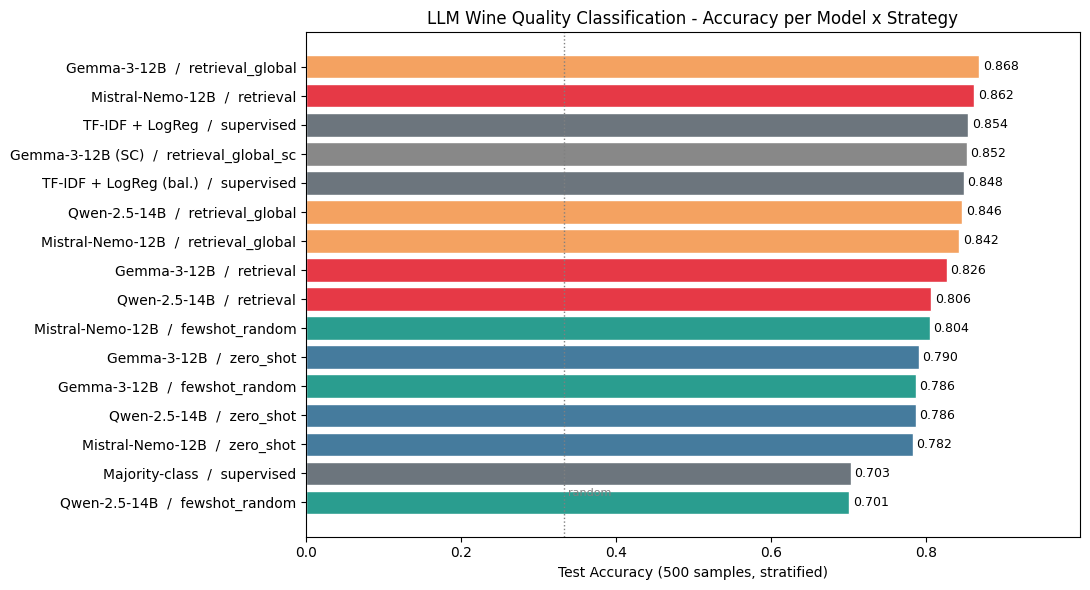

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = results_df.copy()
plot_df["combo"] = plot_df["model"] + "  /  " + plot_df["strategy"]
plot_df = plot_df.sort_values("accuracy", ascending=True)

colors = {"zero_shot": "#457b9d", "fewshot_random": "#2a9d8f",
           "retrieval": "#e63946", "retrieval_global": "#f4a261",
           "supervised": "#6c757d",
           "zero_shot_sc": "#1d3557", "fewshot_random_sc": "#264653",
           "retrieval_sc": "#9d0208"}
bar_colors = [colors.get(s, "#888888") for s in plot_df["strategy"]]
ax.barh(plot_df["combo"], plot_df["accuracy"], color=bar_colors, edgecolor="white")
for i, v in enumerate(plot_df["accuracy"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, max(plot_df["accuracy"]) * 1.15)
ax.set_xlabel(f"Test Accuracy ({N_TEST_EVAL} samples, stratified)")
ax.set_title("LLM Wine Quality Classification - Accuracy per Model x Strategy")
ax.axvline(1 / NUM_CLASSES, color="gray", linestyle=":", linewidth=1)
ax.text(1 / NUM_CLASSES + 0.005, 0.2, "random", color="gray", fontsize=8)
plt.tight_layout()
plt.savefig("llm_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


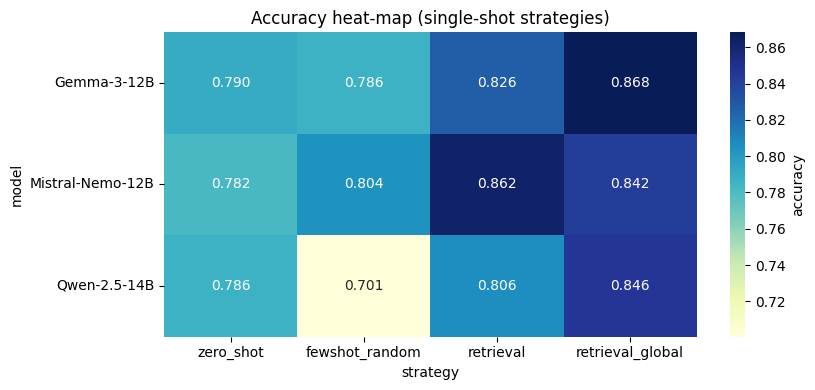

In [17]:
pivot = (results_df[results_df["strategy"].isin(STRATEGIES)]
         .pivot(index="model", columns="strategy", values="accuracy")
         .reindex(columns=STRATEGIES))
fig, ax = plt.subplots(figsize=(8.5, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax,
             cbar_kws={"label": "accuracy"})
ax.set_title("Accuracy heat-map (single-shot strategies)")
plt.tight_layout()
plt.savefig("llm_accuracy_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Confusion Matrices

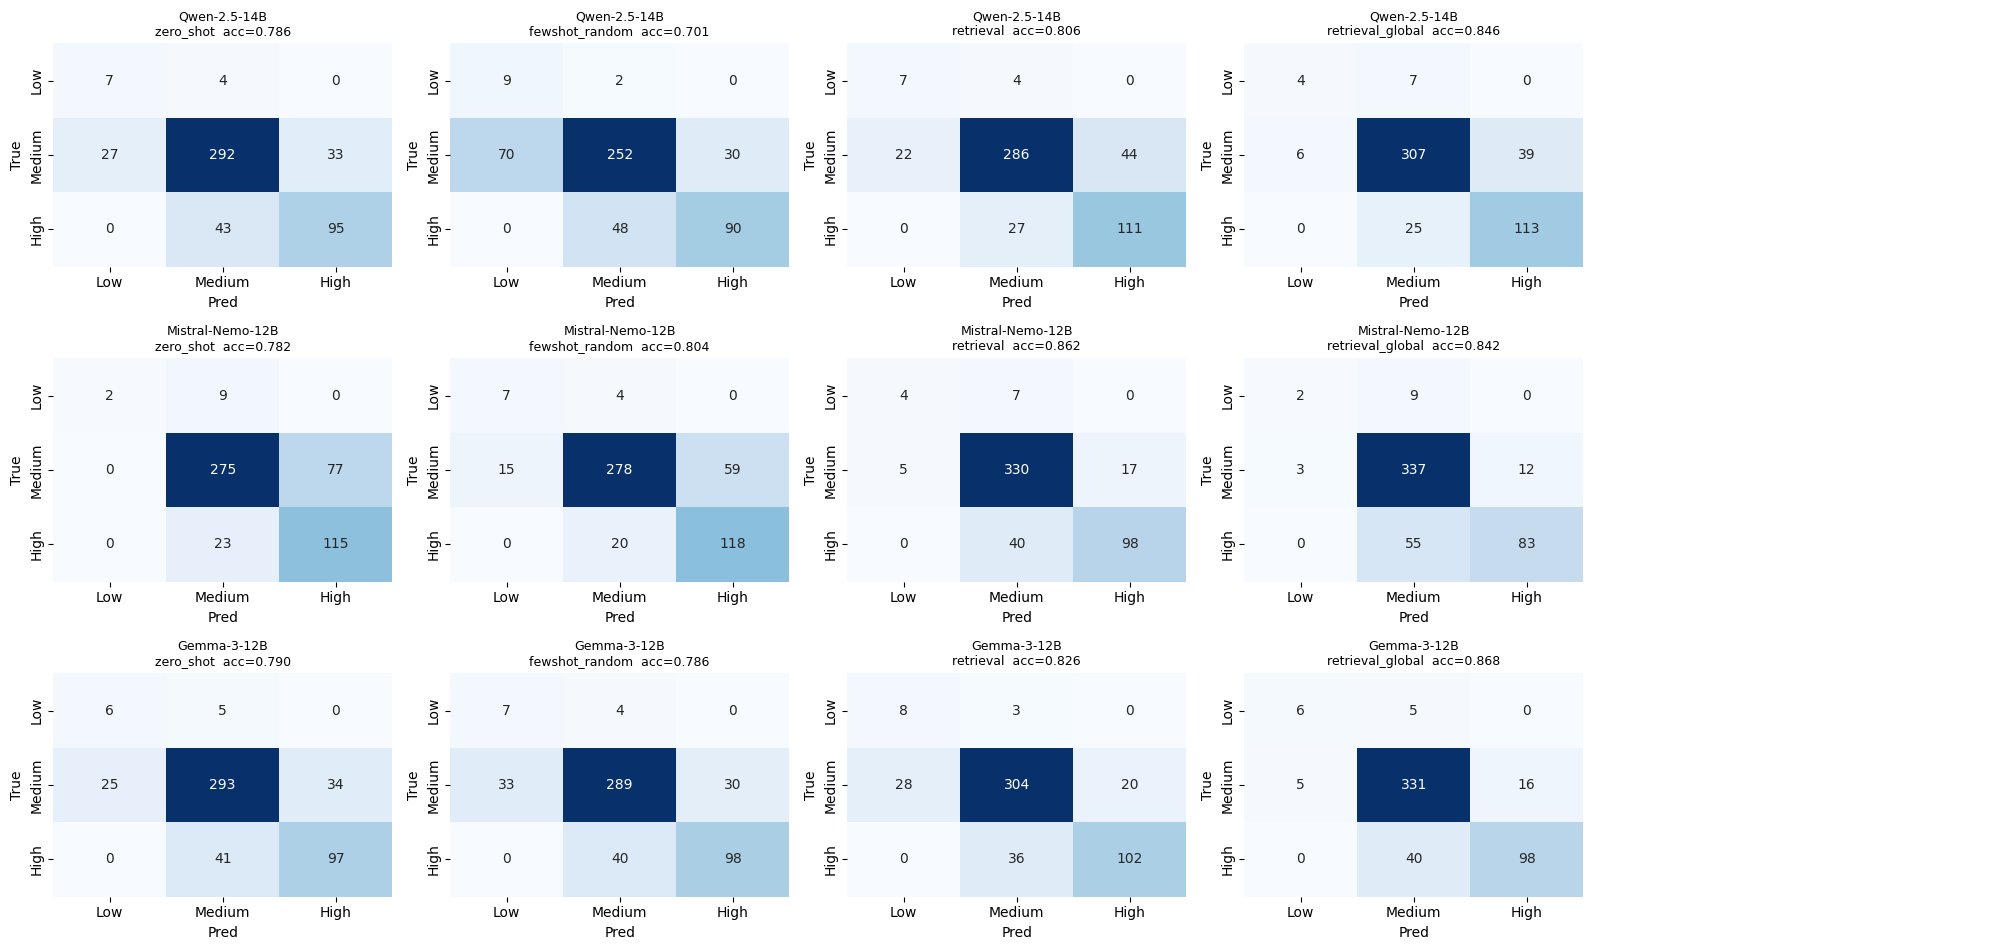

In [18]:
fig, axes = plt.subplots(len(LLM_MODELS), len(STRATEGIES) + (1 if any(r['strategy'].endswith('_sc') for r in all_runs) else 0),
                          figsize=(4 * (len(STRATEGIES) + 1), 3.2 * len(LLM_MODELS)))

if axes.ndim == 1:
    axes = axes.reshape(1, -1)

strategies_full = STRATEGIES + ([best_run["strategy"] + "_sc"] if all_runs[-1]["strategy"].endswith("_sc") else [])
strategy_to_col = {s: i for i, s in enumerate(strategies_full)}
model_to_row    = {name: i for i, (_, name) in enumerate(LLM_MODELS)}
model_to_row[best_run["model"] + " (SC)"] = model_to_row[best_run["model"]]

for ax in axes.flat:
    ax.axis("off")

for run in all_runs:
    base_model_name = run["model"].replace(" (SC)", "")
    if base_model_name not in model_to_row or run["strategy"] not in strategy_to_col:
        continue
    if "(SC)" in run["model"]:
        col = strategy_to_col.get(run["strategy"], len(STRATEGIES))
    else:
        col = strategy_to_col[run["strategy"]]
    row = model_to_row[base_model_name]
    ax = axes[row, col]
    ax.axis("on")
    cm = confusion_matrix(run["labels"], run["preds"], labels=list(range(NUM_CLASSES)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                 xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
    acc = accuracy_score(run["labels"], run["preds"])
    ax.set_title(f"{run['model']}\n{run['strategy']}  acc={acc:.3f}", fontsize=9)
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("llm_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 12b. Minority-Class (Low) Diagnostic

The stratified eval subset contains only ~2% Low-class wines, so per-class recall on
Low is estimated from a handful of examples. This diagnostic samples `N_LOW_DIAG = 100`
additional Low-class reviews from the *full* test split and evaluates:

- the best (model, strategy) LLM configuration, and
- the class-balanced TF-IDF + LogReg baseline

reporting **Low-class recall with a Wilson 95% CI**. This is a targeted robustness
check reported separately from the main table (the subset is intentionally
non-stratified — accuracy on it is not comparable with the main results).

Runtime: ~1 h if the best configuration is Mistral-Nemo + retrieval.

In [19]:
from sentence_transformers import SentenceTransformer
import torch

n_low_available = int((test_df["label"] == 0).sum())
low_diag_df = (test_df[test_df["label"] == 0]
               .sample(n=min(N_LOW_DIAG, n_low_available), random_state=RANDOM_SEED)
               .reset_index(drop=True))
print(f"Low-class diagnostic subset: {len(low_diag_df)} of {n_low_available} "
      f"Low-class test reviews")

device = "cuda" if torch.cuda.is_available() else "cpu"
sbert = SentenceTransformer("BAAI/bge-large-en-v1.5", device=device)
low_emb = sbert.encode(low_diag_df["review"].fillna("").tolist(),
                       batch_size=128, convert_to_numpy=True,
                       normalize_embeddings=True)
del sbert
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

def build_prompt_low(strategy, row, i, rng):
    """Same prompt builders, but retrieval queries use the diagnostic embeddings."""
    if strategy == "retrieval":
        ex = retrieve_exemplars(low_emb[i], balanced=True)
        return SYSTEM_PROMPT, build_retrieval_user_prompt(row, ex, i)
    if strategy == "retrieval_global":
        ex = retrieve_exemplars(low_emb[i], balanced=False)
        return SYSTEM_PROMPT, build_retrieval_user_prompt(row, ex, i)
    return build_prompt(strategy, row, i, rng)

rng_low = np.random.RandomState(RANDOM_SEED)
low_preds_llm, low_fails = [], 0
t0 = time.time()
for i, (_, row) in enumerate(tqdm(low_diag_df.iterrows(), total=len(low_diag_df),
                                  desc=f"Low diag | {best_run['model']}")):
    sys_p, user_p = build_prompt_low(best_run["strategy"], row, i, rng_low)
    out = call_llm(best_run["model_id"], sys_p, user_p)
    pred = parse_label(out)
    if pred is None:
        low_fails += 1
        pred = 1
    low_preds_llm.append(pred)
low_elapsed = time.time() - t0

low_texts = low_diag_df.apply(format_wine, axis=1).tolist()
low_preds_tfidf = baseline_classifiers["TF-IDF + LogReg (bal.)"].predict(
    vec.transform(low_texts))

from scipy.stats import binomtest

def recall_with_wilson(preds):
    k = int(np.sum(np.asarray(preds) == 0))
    n = len(preds)
    ci = binomtest(k, n).proportion_ci(confidence_level=0.95, method="wilson")
    return k / n, ci.low, ci.high

low_rows = []
for name, preds in [(f"{best_run['model']} ({best_run['strategy']})", low_preds_llm),
                    ("TF-IDF + LogReg (bal.)", low_preds_tfidf)]:
    rec, lo, hi = recall_with_wilson(preds)
    dist = Counter(np.asarray(preds).tolist())
    low_rows.append({
        "model":          name,
        "low_recall":     round(rec, 3),
        "wilson_ci_lo":   round(lo, 3),
        "wilson_ci_hi":   round(hi, 3),
        "pred_Low":       dist.get(0, 0),
        "pred_Medium":    dist.get(1, 0),
        "pred_High":      dist.get(2, 0),
        "n":              len(preds),
    })
low_diag_results = pd.DataFrame(low_rows)
low_diag_results.to_csv("llm_low_diagnostic.csv", index=False)
display(low_diag_results)
print(f"\nLLM diagnostic time: {low_elapsed/60:.1f} min, parse fails: {low_fails}")
print("\nLaTeX:")
print(low_diag_results.to_latex(index=False, escape=True))

Low-class diagnostic subset: 100 of 452 Low-class test reviews


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Low diag | Gemma-3-12B:   0%|          | 0/100 [00:00<?, ?it/s]

,model,low_recall,wilson_ci_lo,wilson_ci_hi,pred_Low,pred_Medium,pred_High,n
0,Gemma-3-12B (retrieval_global),0.48,0.385,0.577,48,52,0,100
1,TF-IDF + LogReg (bal.),0.77,0.678,0.842,77,23,0,100



LLM diagnostic time: 4.4 min, parse fails: 0

LaTeX:
\begin{tabular}{lrrrrrrr}
\toprule
model & low\_recall & wilson\_ci\_lo & wilson\_ci\_hi & pred\_Low & pred\_Medium & pred\_High & n \\
\midrule
Gemma-3-12B (retrieval\_global) & 0.480000 & 0.385000 & 0.577000 & 48 & 52 & 0 & 100 \\
TF-IDF + LogReg (bal.) & 0.770000 & 0.678000 & 0.842000 & 77 & 23 & 0 & 100 \\
\bottomrule
\end{tabular}



## 12c. Worked Example Export

A complete worked example - the raw input, the *full* assembled retrieval-augmented
prompt (system prompt + retrieved exemplars + query), and the raw model output.
Writes `worked_example.md` next to the notebook.

In [20]:
ex_idx = int(np.where(test_eval_df["label"].values == 2)[0][0])
ex_row = test_eval_df.iloc[ex_idx]

sys_p, user_p = build_prompt_retrieval(ex_row, ex_idx)
raw_out = call_llm(best_run["model_id"], sys_p, user_p)
pred = parse_label(raw_out)

md = f"""# Worked Example: Class-Balanced Retrieval-Augmented Prompting

One complete end-to-end example from the evaluation pipeline. Model: **{best_run['model']}** (Ollama `{best_run['model_id']}`,
Q4_K_M, deterministic decoding: temperature 0.0, top-p 1.0, max 8 tokens).

## 1. Raw test instance

| Field | Value |
|---|---|
| Country | {ex_row['country']} |
| Region | {ex_row['region']} |
| Price | {f"{ex_row['price']:.0f} USD" if pd.notna(ex_row['price']) else 'unknown'} |
| WineEnthusiast score | {int(ex_row['rating'])} |
| True class | {int(ex_row['label'])} ({CLASS_NAMES[int(ex_row['label'])]}) |

**Review text:**

> {str(ex_row['review'])}

## 2. System prompt (identical across all strategies)

```text
{sys_p}
```

## 3. User prompt (class-balanced retrieval, K=6: top-2 exemplars per class by BGE cosine similarity)

```text
{user_p}
```

## 4. Raw model output

```text
{raw_out}
```

## 5. Parsed prediction

Predicted class: **{pred} ({CLASS_NAMES[pred] if pred is not None else 'parse failure'})** — true class: **{int(ex_row['label'])} ({CLASS_NAMES[int(ex_row['label'])]})**

The regex parser extracts the first standalone digit in {{0, 1, 2}} from the response.
"""

with open("worked_example.md", "w", encoding="utf-8") as f:
    f.write(md)

print(f"Saved: worked_example.md  (model={best_run['model']}, "
      f"pred={pred}, true={int(ex_row['label'])})")

Saved: worked_example.md  (model=Gemma-3-12B, pred=1, true=2)


## 13. Save Results

In [21]:
results_df.round(4).to_csv("llm_results.csv", index=False)
print("Saved: llm_results.csv")
print("Saved: llm_accuracy_comparison.png")
print("Saved: llm_accuracy_heatmap.png")
print("Saved: llm_confusion_matrices.png")
print("Saved: llm_stats_ci.csv, llm_stats_mcnemar.csv (cell 10b)")
print("Saved: llm_per_class.csv (cell 10c)")
print("Saved: llm_low_diagnostic.csv (cell 12b)")
print("Saved: worked_example.md (cell 12c)")

import pickle
serialisable = []
for r in all_runs:
    serialisable.append({
        "model":          r["model"],
        "strategy":       r["strategy"],
        "preds":          np.asarray(r["preds"]).tolist(),
        "labels":         np.asarray(r["labels"]).tolist(),
        "raw":            r["raw"][:50] if isinstance(r["raw"], list) else None,
        "parse_failures": r["parse_failures"],
        "elapsed_s":      r["elapsed_s"],
    })
with open("llm_runs.pkl", "wb") as f:
    pickle.dump(serialisable, f)
print("Saved: llm_runs.pkl  (runs metadata + first 50 raw outputs per run)\n")

latex_cols = ["model", "strategy", "accuracy", "f1_weighted", "cohen_kappa",
               "mcc", "mae_ordinal", "rank_acc_pm1", "spearman_rho"]
print(results_df[latex_cols].round(4).to_latex(index=False, escape=True))


Saved: llm_results.csv
Saved: llm_accuracy_comparison.png
Saved: llm_accuracy_heatmap.png
Saved: llm_confusion_matrices.png
Saved: llm_stats_ci.csv, llm_stats_mcnemar.csv (cell 10b)
Saved: llm_per_class.csv (cell 10c)
Saved: llm_low_diagnostic.csv (cell 12b)
Saved: worked_example.md (cell 12c)
Saved: llm_runs.pkl  (runs metadata + first 50 raw outputs per run)

\begin{tabular}{llrrrrrrr}
\toprule
model & strategy & accuracy & f1\_weighted & cohen\_kappa & mcc & mae\_ordinal & rank\_acc\_pm1 & spearman\_rho \\
\midrule
Gemma-3-12B & retrieval\_global & 0.868300 & 0.865100 & 0.678300 & 0.683200 & 0.131700 & 1.000000 & 0.710900 \\
Mistral-Nemo-12B & retrieval & 0.862300 & 0.858300 & 0.662200 & 0.667200 & 0.137700 & 1.000000 & 0.698200 \\
TF-IDF + LogReg & supervised & 0.854300 & 0.845600 & 0.634800 & 0.642100 & 0.145700 & 1.000000 & 0.663100 \\
Gemma-3-12B (SC) & retrieval\_global\_sc & 0.852300 & 0.848200 & 0.635700 & 0.643400 & 0.147700 & 1.000000 & 0.677400 \\
TF-IDF + LogReg (bal.) & 